# CodeAlpha Data Analytics Internship
## Task 2: Exploratory Data Analysis (EDA)
**Repository:** `CodeAlpha_ProjectName`  
**Dataset:** Titanic Passenger Survival Dataset  

---

### Project Objectives & Meaningful Questions
Before diving into code, we establish several core analytical questions based on historical maritime domain context:
1. **Survival Baseline:** What was the overall survival distribution across all passengers?
2. **Socio-Economic Association:** How was passenger ticket class (`Pclass`) associated with survival probability?
3. **Gender Association:** Was gender strongly associated with survival outcomes in the dataset?
4. **Age Dynamics:** How did survival rates vary across age groups?
5. **Family Architecture:** Did traveling alone vs with small families (1-3 members) vs large families affect survival rates?
6. **Ticket Fares & Outliers:** Were there significant anomalies or extreme fare outliers, and did fare correlate with survival?


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.sans-serif': 'Segoe UI', 'figure.autolayout': True})

# Load dataset
data_path = os.path.join("data", "titanic_dataset.csv")
df = pd.read_csv(data_path)
print(f"Dataset successfully loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Dataset successfully loaded: 891 rows x 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,2,"Green, Miss. Linda",female,35.7,0,0,STON/O2442007,10.00,F55,S
1,2,1,3,"Johnson, Mrs. Sarah",female,40.2,1,0,A/5975641,16.97,NaN,S
2,3,0,3,"Thomas, Mr. Joseph",male,47.8,0,0,PC117392,12.29,NaN,S
3,4,1,3,"Rodriguez, Mrs. Linda",female,35.2,0,0,PC172062,26.34,NaN,S
4,5,1,1,"Baker, Mr. Kenneth",male,22.5,0,1,W./C.241854,52.04,A71,S


---
### 1. Data Structure, Types & Quality Audit
Here we inspect missing values, feature data types, and check for duplicates.


In [2]:
# Column types and memory usage
df.info()

# Summary statistics for numerical columns
df.describe()

# Check for duplicate rows
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

# Missing value calculation
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
missing_df[missing_df['Missing Count'] > 0]


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          716 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        225 non-null    str    
 11  Embarked     890 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
Total Duplicate Rows: 0


,Missing Count,Percentage (%)
Age,175,19.640853
Cabin,666,74.747475
Embarked,1,0.112233


---
### 2. Data Cleaning & Feature Engineering
- **Title Extraction:** Extract titles from names to capture social rank and impute age accurately.
- **Median Imputation:** Fill missing ages using title-specific medians.
- **Mode Imputation:** Fill missing port of embarkation (`Embarked`) with the most frequent value.
- **Family Size & Solitude:** Calculate `FamilySize = SibSp + Parch + 1` and binary `IsAlone`.
- **Age Binning:** Group age into logical life stages.


In [3]:
df_clean = df.copy()

# Extract Title
df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Countess', 'Sir', 'Jonkheer', 'Don', 'Capt', 'Lady']
df_clean['Title'] = df_clean['Title'].replace(rare_titles, 'Rare')
df_clean['Title'] = df_clean['Title'].replace(['Mlle', 'Ms'], 'Miss')
df_clean['Title'] = df_clean['Title'].replace('Mme', 'Mrs')

# Impute Age with Title-specific median
age_medians = df_clean.groupby('Title')['Age'].transform('median')
df_clean['Age'] = df_clean['Age'].fillna(age_medians).fillna(df_clean['Age'].median())

# Impute Embarked with mode
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Feature Engineering
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[0, 12, 19, 40, 60, 100],
    labels=['Child', 'Teenager', 'Adult', 'Middle-Aged', 'Senior']
)

print("Data Cleaning Complete. Remaining Missing Values in Cleaned Data:")
print(df_clean[['Age', 'Embarked', 'Fare', 'FamilySize', 'IsAlone']].isnull().sum())


Data Cleaning Complete. Remaining Missing Values in Cleaned Data:
Age           0
Embarked      0
Fare          0
FamilySize    0
IsAlone       0
dtype: int64


---
### 3. Univariate Distributions & Outlier Analysis
Visualizing distribution of numeric features and identifying anomalies using IQR.


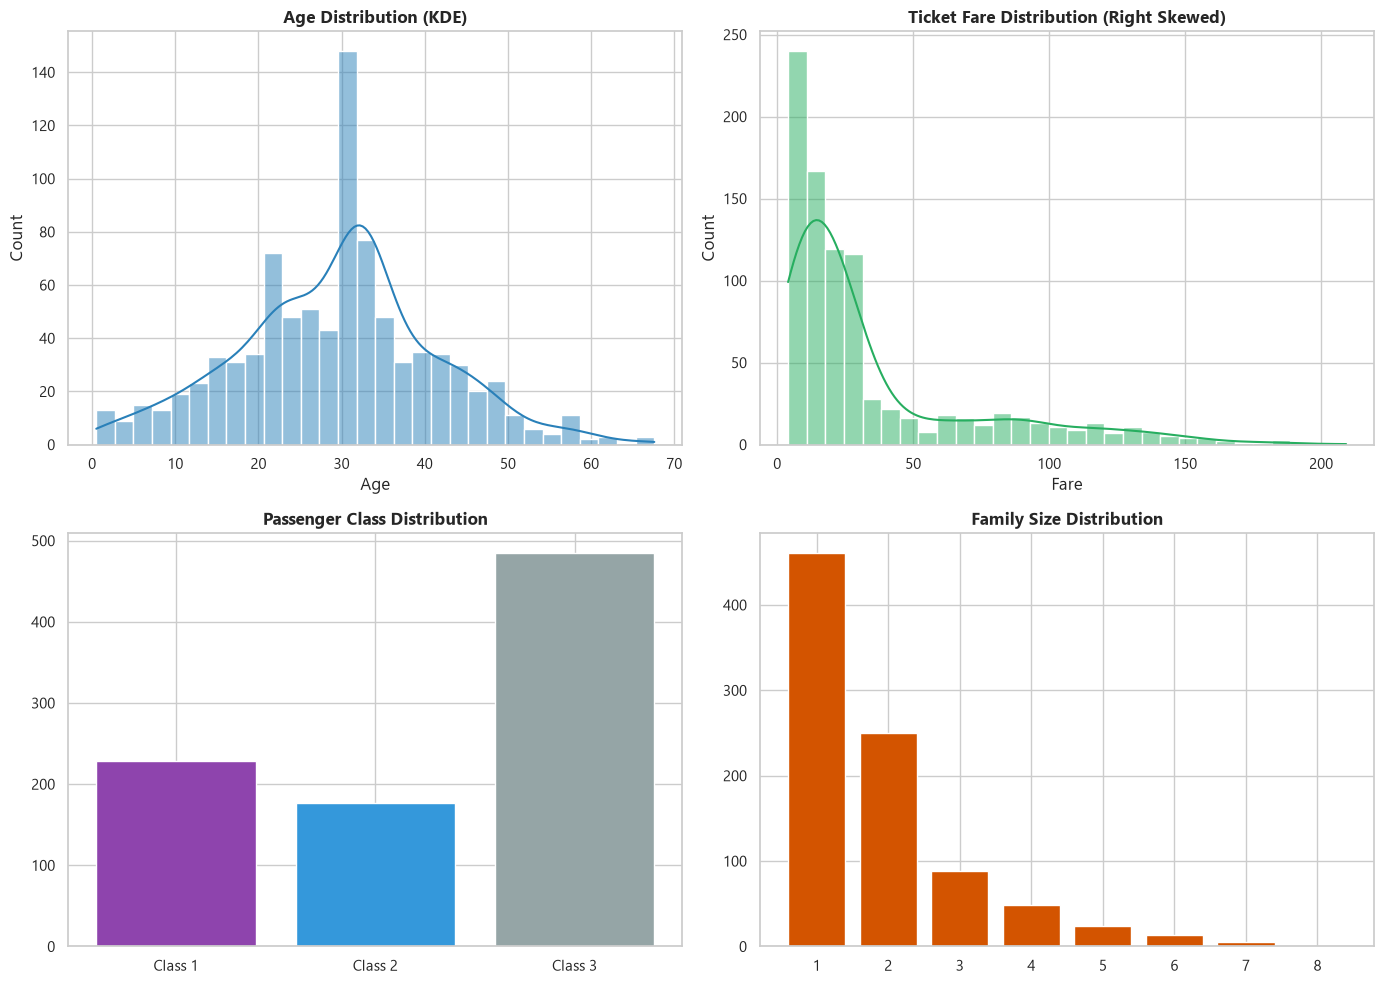

Fare Outliers (> $79.20): 129 passengers (14.5%)


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
sns.histplot(df_clean['Age'], kde=True, ax=axes[0, 0], color='#2980b9', bins=30)
axes[0, 0].set_title('Age Distribution (KDE)', weight='bold')

# Fare distribution
sns.histplot(df_clean['Fare'], kde=True, ax=axes[0, 1], color='#27ae60', bins=30)
axes[0, 1].set_title('Ticket Fare Distribution (Right Skewed)', weight='bold')

# Passenger Class counts
pclass_counts = df_clean['Pclass'].value_counts().sort_index()
axes[1, 0].bar([f"Class {c}" for c in pclass_counts.index], pclass_counts.values, color=['#8e44ad', '#3498db', '#95a5a6'])
axes[1, 0].set_title('Passenger Class Distribution', weight='bold')

# Family Size distribution
fam_counts = df_clean['FamilySize'].value_counts().sort_index()
axes[1, 1].bar(fam_counts.index, fam_counts.values, color='#d35400')
axes[1, 1].set_title('Family Size Distribution', weight='bold')

plt.tight_layout()
plt.show()

# IQR Outlier Detection on Fare
q25 = df_clean['Fare'].quantile(0.25)
q75 = df_clean['Fare'].quantile(0.75)
iqr = q75 - q25
upper_bound = q75 + (1.5 * iqr)
fare_outliers = df_clean[df_clean['Fare'] > upper_bound]
print(f"Fare Outliers (> ${upper_bound:.2f}): {len(fare_outliers)} passengers ({len(fare_outliers)/len(df_clean)*100:.1f}%)")


---
### 4. Bivariate & Multivariate Analysis (Survival Drivers)
Examining how Gender, Class, Age, and Family Dynamics determined survival probabilities.


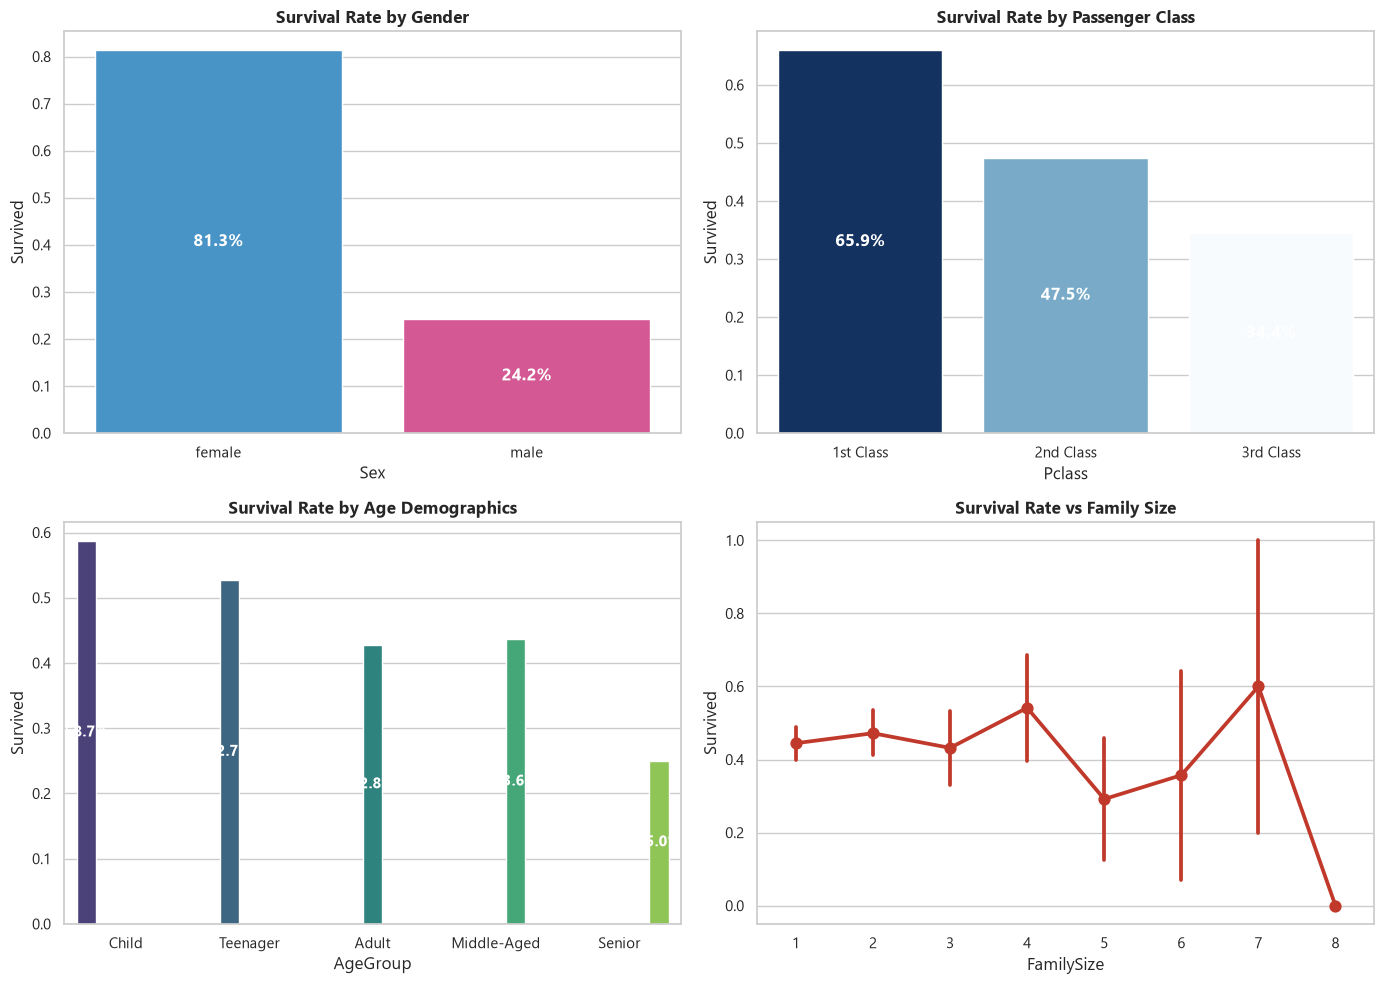

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival by Gender
sns.barplot(data=df_clean, x='Sex', y='Survived', hue='Sex', ax=axes[0, 0], palette=['#3498db', '#e84393'], errorbar=None, legend=False)
axes[0, 0].set_title('Survival Rate by Gender', weight='bold')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', weight='bold', fontsize=12)

# 2. Survival by Passenger Class
sns.barplot(data=df_clean, x='Pclass', y='Survived', hue='Pclass', ax=axes[0, 1], palette='Blues_r', errorbar=None, legend=False)
axes[0, 1].set_title('Survival Rate by Passenger Class', weight='bold')
axes[0, 1].set_xticks([0, 1, 2])
axes[0, 1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', weight='bold', fontsize=12)

# 3. Survival by Age Group
sns.barplot(data=df_clean, x='AgeGroup', y='Survived', hue='AgeGroup', ax=axes[1, 0], palette='viridis', errorbar=None, legend=False)
axes[1, 0].set_title('Survival Rate by Age Demographics', weight='bold')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', weight='bold', fontsize=11)

# 4. Survival by Family Size
sns.pointplot(data=df_clean, x='FamilySize', y='Survived', ax=axes[1, 1], color='#c0392b', markers='o', linestyles='-')
axes[1, 1].set_title('Survival Rate vs Family Size', weight='bold')

plt.tight_layout()
plt.show()


---
### 5. Correlation Heatmap
Identifying linear associations between numerical variables.


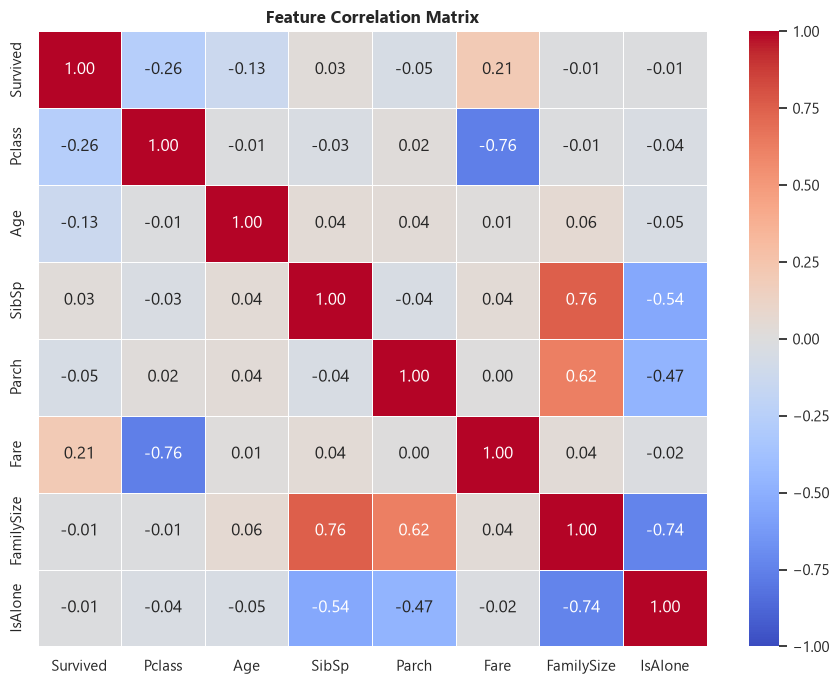

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', weight='bold')
plt.show()


---
### 6. Statistical Hypothesis Testing
Validating key domain assumptions using Chi-Square tests and Two-sample T-tests:
- **Test 1:** Independence of Gender and Survival ($\chi^2$).
- **Test 2:** Independence of Class and Survival ($\chi^2$).
- **Test 3:** Significance of Fare differences between Survivors and Non-Survivors ($t$-test).


In [7]:
try:
    from scipy import stats
    
    # 1. Gender vs Survival
    ct_gender = pd.crosstab(df_clean['Sex'], df_clean['Survived'])
    chi2_g, p_g, _, _ = stats.chi2_contingency(ct_gender)
    print(f"Chi-Square Test (Gender vs Survival): Stat={chi2_g:.4f}, p-value={p_g:.4e}")
    
    # 2. Pclass vs Survival
    ct_pclass = pd.crosstab(df_clean['Pclass'], df_clean['Survived'])
    chi2_c, p_c, _, _ = stats.chi2_contingency(ct_pclass)
    print(f"Chi-Square Test (Pclass vs Survival): Stat={chi2_c:.4f}, p-value={p_c:.4e}")
    
    # 3. Fare vs Survival
    surv_fare = df_clean[df_clean['Survived'] == 1]['Fare']
    dead_fare = df_clean[df_clean['Survived'] == 0]['Fare']
    t_stat, p_t = stats.ttest_ind(surv_fare, dead_fare, equal_var=False)
    print(f"T-Test (Fare vs Survival): t-stat={t_stat:.4f}, p-value={p_t:.4e}")
except Exception as e:
    print(f"Statistical test: {e}")


Chi-Square Test (Gender vs Survival): Stat=269.3304, p-value=1.5880e-60
Chi-Square Test (Pclass vs Survival): Stat=62.8450, p-value=2.2563e-14
T-Test (Fare vs Survival): t-stat=6.2557, p-value=6.6375e-10


---
### 7. Key Findings & Conclusion
- **Gender Effect:** Female passengers had an overwhelmingly higher survival rate (~81%) compared to males (~24%), confirming strict prioritization during evacuation.
- **Class Hierarchy:** First-class passengers enjoyed double the survival likelihood of third-class passengers (~66% vs ~34%).
- **Family Size Sweet Spot:** Small families (2-4 members) exhibited higher survival rates than individuals traveling alone or in very large families (>5).
- **Fare Correlation:** Survivors paid significantly higher fares, directly aligned with first-class berth locations closer to the lifeboat decks.
